In [8]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import ic2.utils as uti
import visualizacoes as vis
import analise_descritiva as ad
import processamento as prc
import outliers as out
import imputacao as imp
import format as frm  

ModuleNotFoundError: No module named 'ic2'

# Gráficos de barras para comparação de resultados

Eu quero gerar um gráfico de barras para cada base de dados. Cada barra deve representar uma variável. Acho que a ideia é comparar o grau de complexão entre cada método? Pensando agora, se esse for o objetivo, acho que a matrix da biblioteca missingno já faça isso melhor

In [1]:
from pcj.utils import BASE_DIR

print(BASE_DIR)

C:\_Master\Programacao\Guilherme-Betta\IC2


In [7]:
from utils import dados

dados_brutos, metadados, variaveis = dados(r"data\input\dados_brutos.xlsx")
brutos_prontos, metadados, variaveis = dados(r"data\input\brutos_prontos.xlsx")
dados_limpos, metadados, variaveis = dados(r"data\input\dados_limpos.xlsx")
# remocao_zscore, metadados, variaveis = dados(r"data\out\limpos_zscore.xlsx")
# remocao_iqr, metadados, variaveis = dados(r"data\out\limpos_iqr.xlsx")
# limpos_imput_media, metadados, variaveis = dados(r"data\out\limpos_mean.xlsx")
# limpos_imput_mediana, metadados, variaveis = dados(r"data\out\limpos_mediana.xlsx")
# limpos_imput_knn, metadados, variaveis = dados(r"data\out\limpos_knn.xlsx")
# zscore_imput_media, metadados, variaveis = dados(r"data\out\zscore_mean.xlsx")
# zscore_imput_mediana, metadados, variaveis = dados(r"data\out\zscore_mediana.xlsx")
# zscore_imput_knn, metadados, variaveis = dados(r"data\out\zscore_knn.xlsx")
# iqr_imput_media, metadados, variaveis = dados(r"data\out\iqr_mean.xlsx")
# iqr_imput_mediana, metadados, variaveis = dados(r"data\out\iqr_mediana.xlsx")
# iqr_imput_knn, metadados, variaveis = dados(r"data\out\iqr_knn.xlsx")

In [19]:
teste, metadados, variaveis = dados(r"data\output\imput_median20260519_115412.xlsx")

if teste.columns[teste.isna().any()].array.size == 0:
    print('Vazio')

Vazio


In [20]:
if dados_brutos.columns[dados_brutos.isna().any()].array.size == 0:
    print('Vazio')
else:
    print('Cheio')

Cheio


In [4]:
variaveis = []

for variavel in dados_prontos.columns:
    variaveis.append(variavel)

# for variavel in dados_limpos.columns:
#     variaveis.append(variavel)

from utils import METADADOS

for metadado in METADADOS:
    variaveis.remove(metadado)

data_bases = [dados_brutos, dados_prontos, dados_limpos, 
              remocao_zscore, remocao_iqr, 
              limpos_imput_media, limpos_imput_mediana, limpos_imput_knn, 
              zscore_imput_media, zscore_imput_mediana, zscore_imput_knn, 
              iqr_imput_media, iqr_imput_mediana, iqr_imput_knn]

In [ ]:
for base in data_bases:
    for variavel in variaveis:
        try:
            sns.barplot(data=base,
                        x=base[variavel],
                        y=variavel)
        except ValueError:
            pass

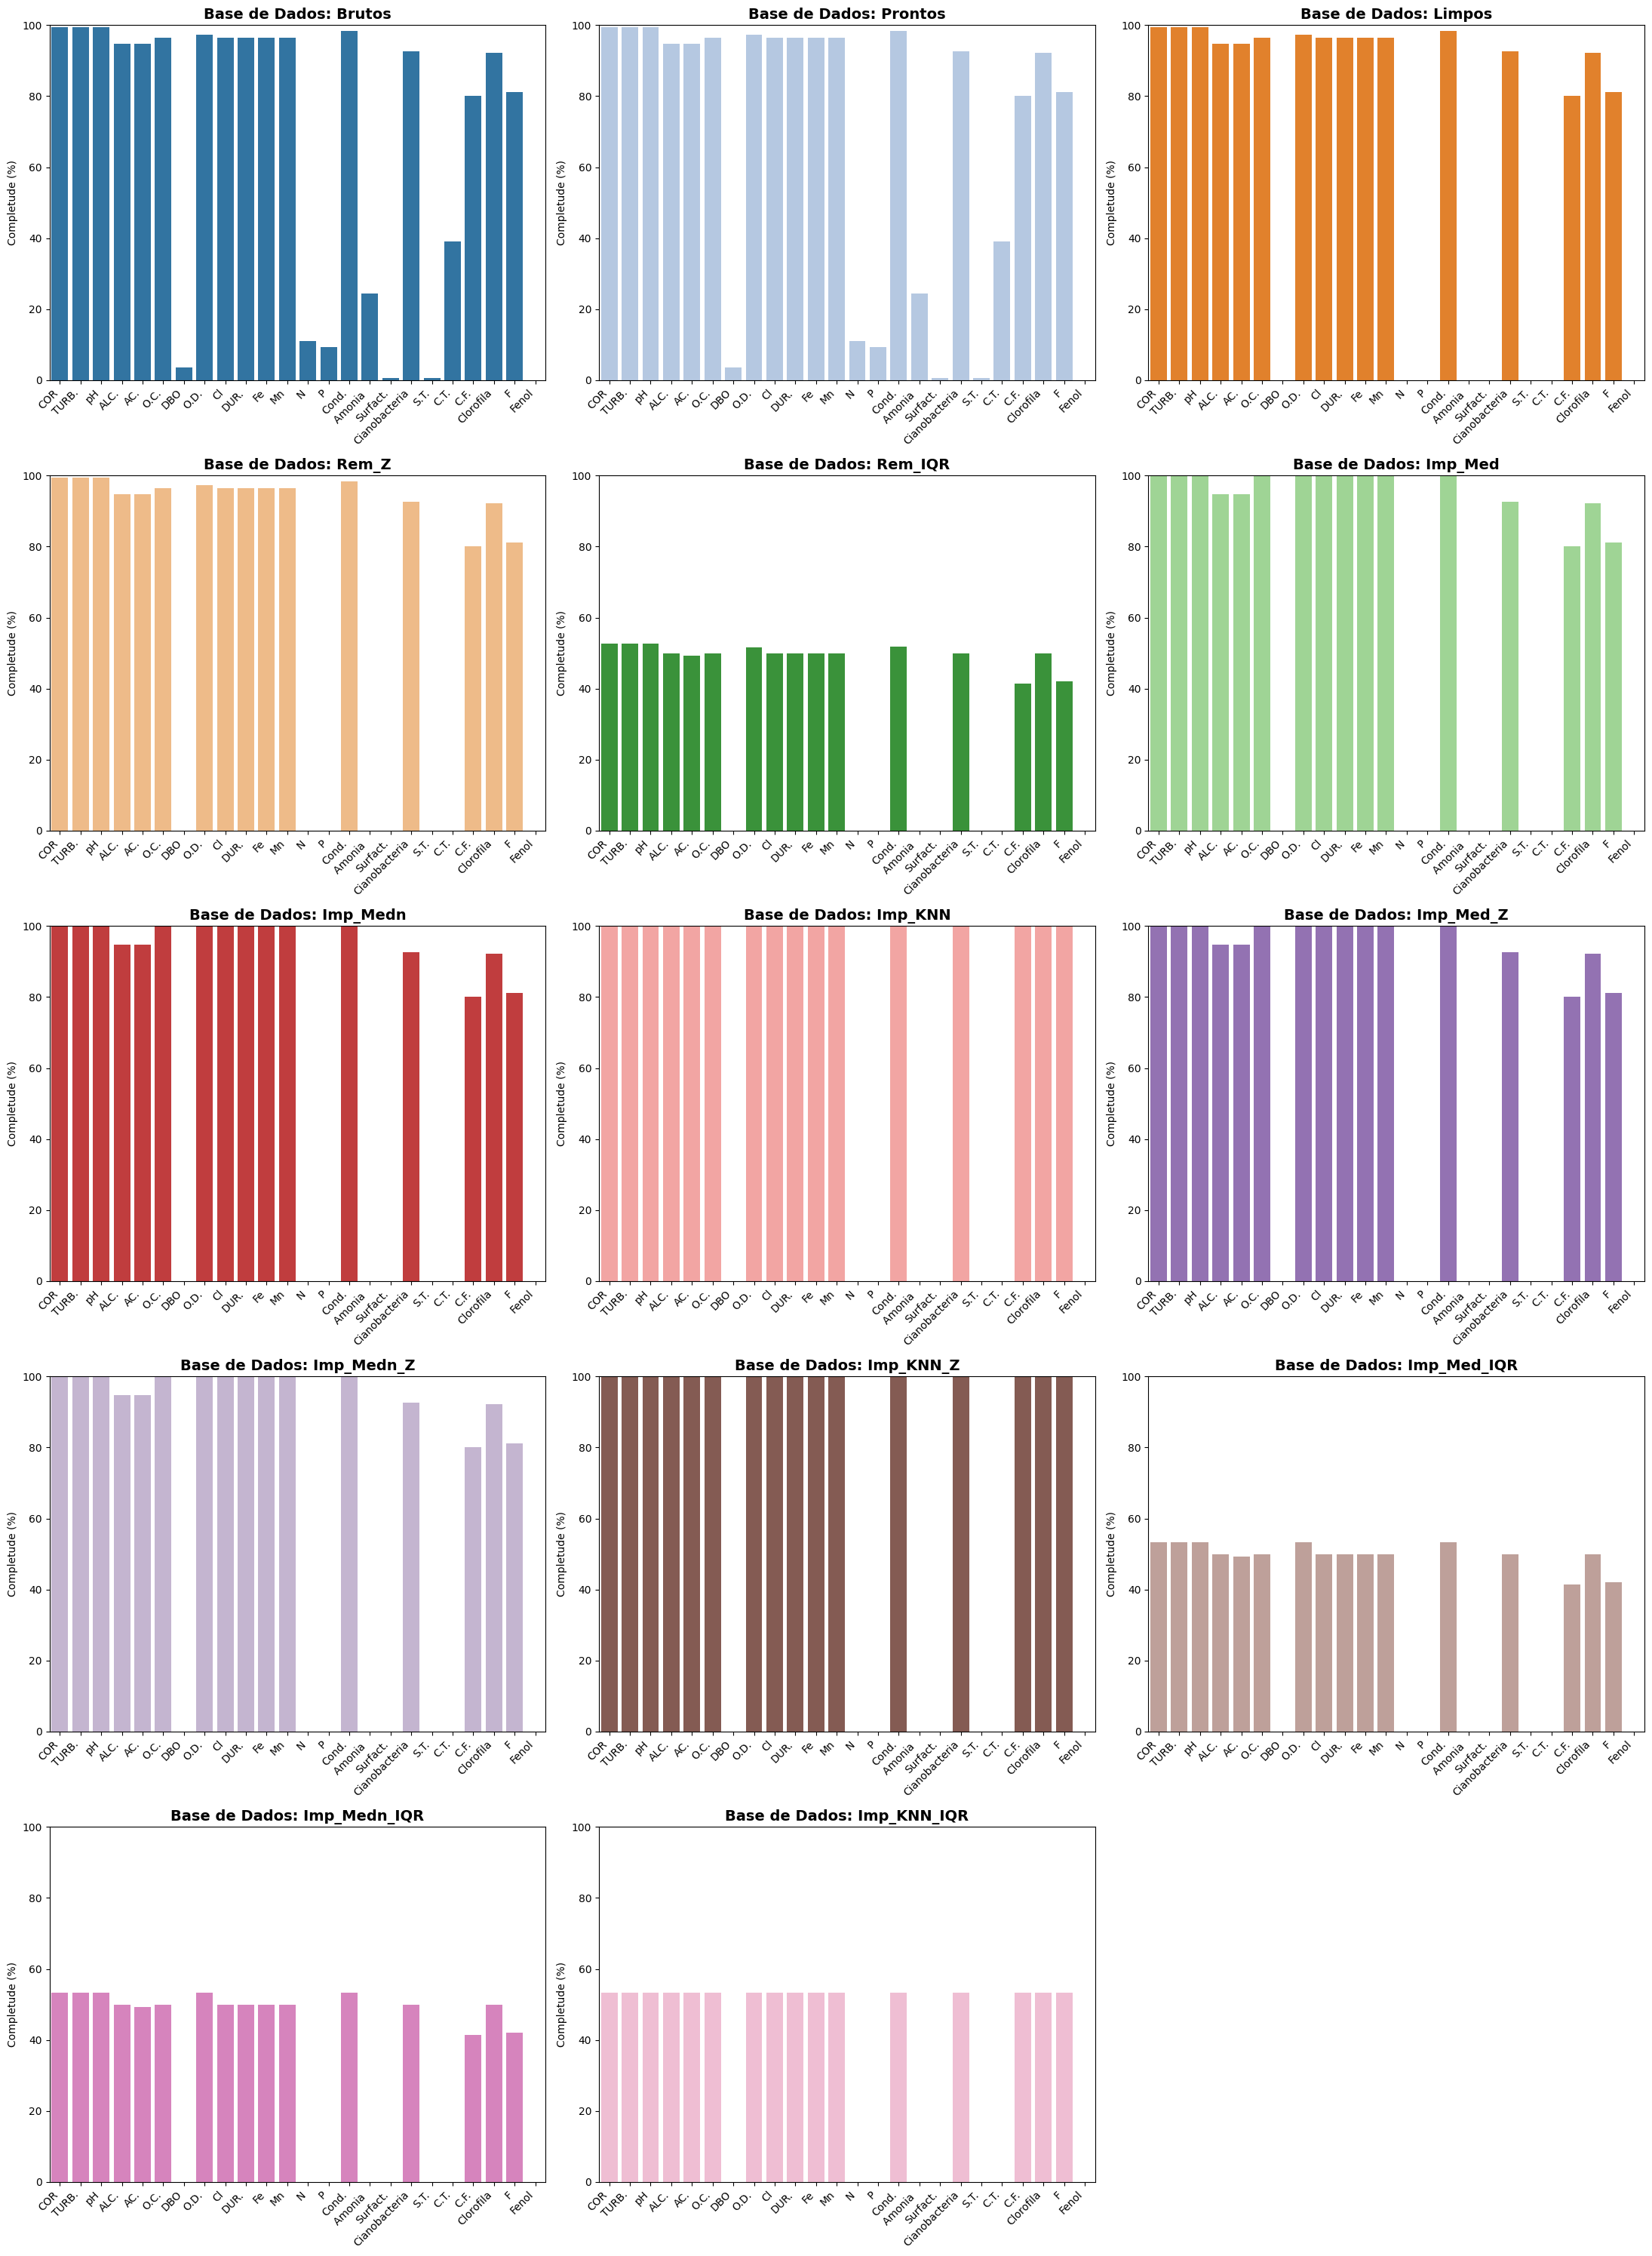

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

nomes_bases = [
    'Brutos', 'Prontos', 'Limpos', 'Rem_Z', 'Rem_IQR', 
    'Imp_Med', 'Imp_Medn', 'Imp_KNN', 
    'Imp_Med_Z', 'Imp_Medn_Z', 'Imp_KNN_Z', 
    'Imp_Med_IQR', 'Imp_Medn_IQR', 'Imp_KNN_IQR'
]

# --- DEFININDO AS CORES ---
# Pegamos uma paleta com 14 cores distintas (tab20 é ótima para isso)
paleta = sns.color_palette("tab20", len(nomes_bases))
# Criamos um dicionário vinculando cada nome de base a uma cor
cores_das_bases = {base: cor for base, cor in zip(nomes_bases, paleta)}

# 1. Pegar o total máximo de linhas da primeira base
total_linhas_maximo = len(data_bases[0]) 
resumo_por_base = {}

for i, base in enumerate(data_bases):
    nome_da_base = nomes_bases[i]
    porcentagens_desta_base = []
    
    for variavel in variaveis:
        if variavel in base.columns:
            coluna_numerica = pd.to_numeric(base[variavel], errors='coerce')
            qtd_validos = coluna_numerica.count()
        else:
            qtd_validos = 0
            
        porcentagem = (qtd_validos / total_linhas_maximo) * 100
        porcentagens_desta_base.append(porcentagem)
        
    resumo_por_base[nome_da_base] = porcentagens_desta_base

num_bases = len(nomes_bases)
colunas_no_grafico = 3
linhas_no_grafico = math.ceil(num_bases / colunas_no_grafico) 

# --- AJUSTANDO O ESPAÇO ---
# Aumentamos a largura de 18 para 22 e a altura proporcionalmente
fig, axes = plt.subplots(linhas_no_grafico, colunas_no_grafico, figsize=(22, 6 * linhas_no_grafico))
axes = axes.flatten()

for i, nome_da_base in enumerate(nomes_bases):
    ax = axes[i]
    
    # --- APLICANDO A COR DA BASE ---
    sns.barplot(
        x=variaveis, 
        y=resumo_por_base[nome_da_base], 
        ax=ax, 
        color=cores_das_bases[nome_da_base] # Puxa a cor específica desta base
    )
    
    ax.set_ylim(0, 100) 
    ax.set_title(f'Base de Dados: {nome_da_base}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Completude (%)') 
    
    # --- MELHORANDO A LEITURA DO EIXO X ---
    # Rotação de 45 graus e alinhamento à direita (ha='right') evita sobreposição
    ax.set_xticks(range(len(variaveis)))
    ax.set_xticklabels(variaveis, rotation=45, ha='right')

for j in range(num_bases, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

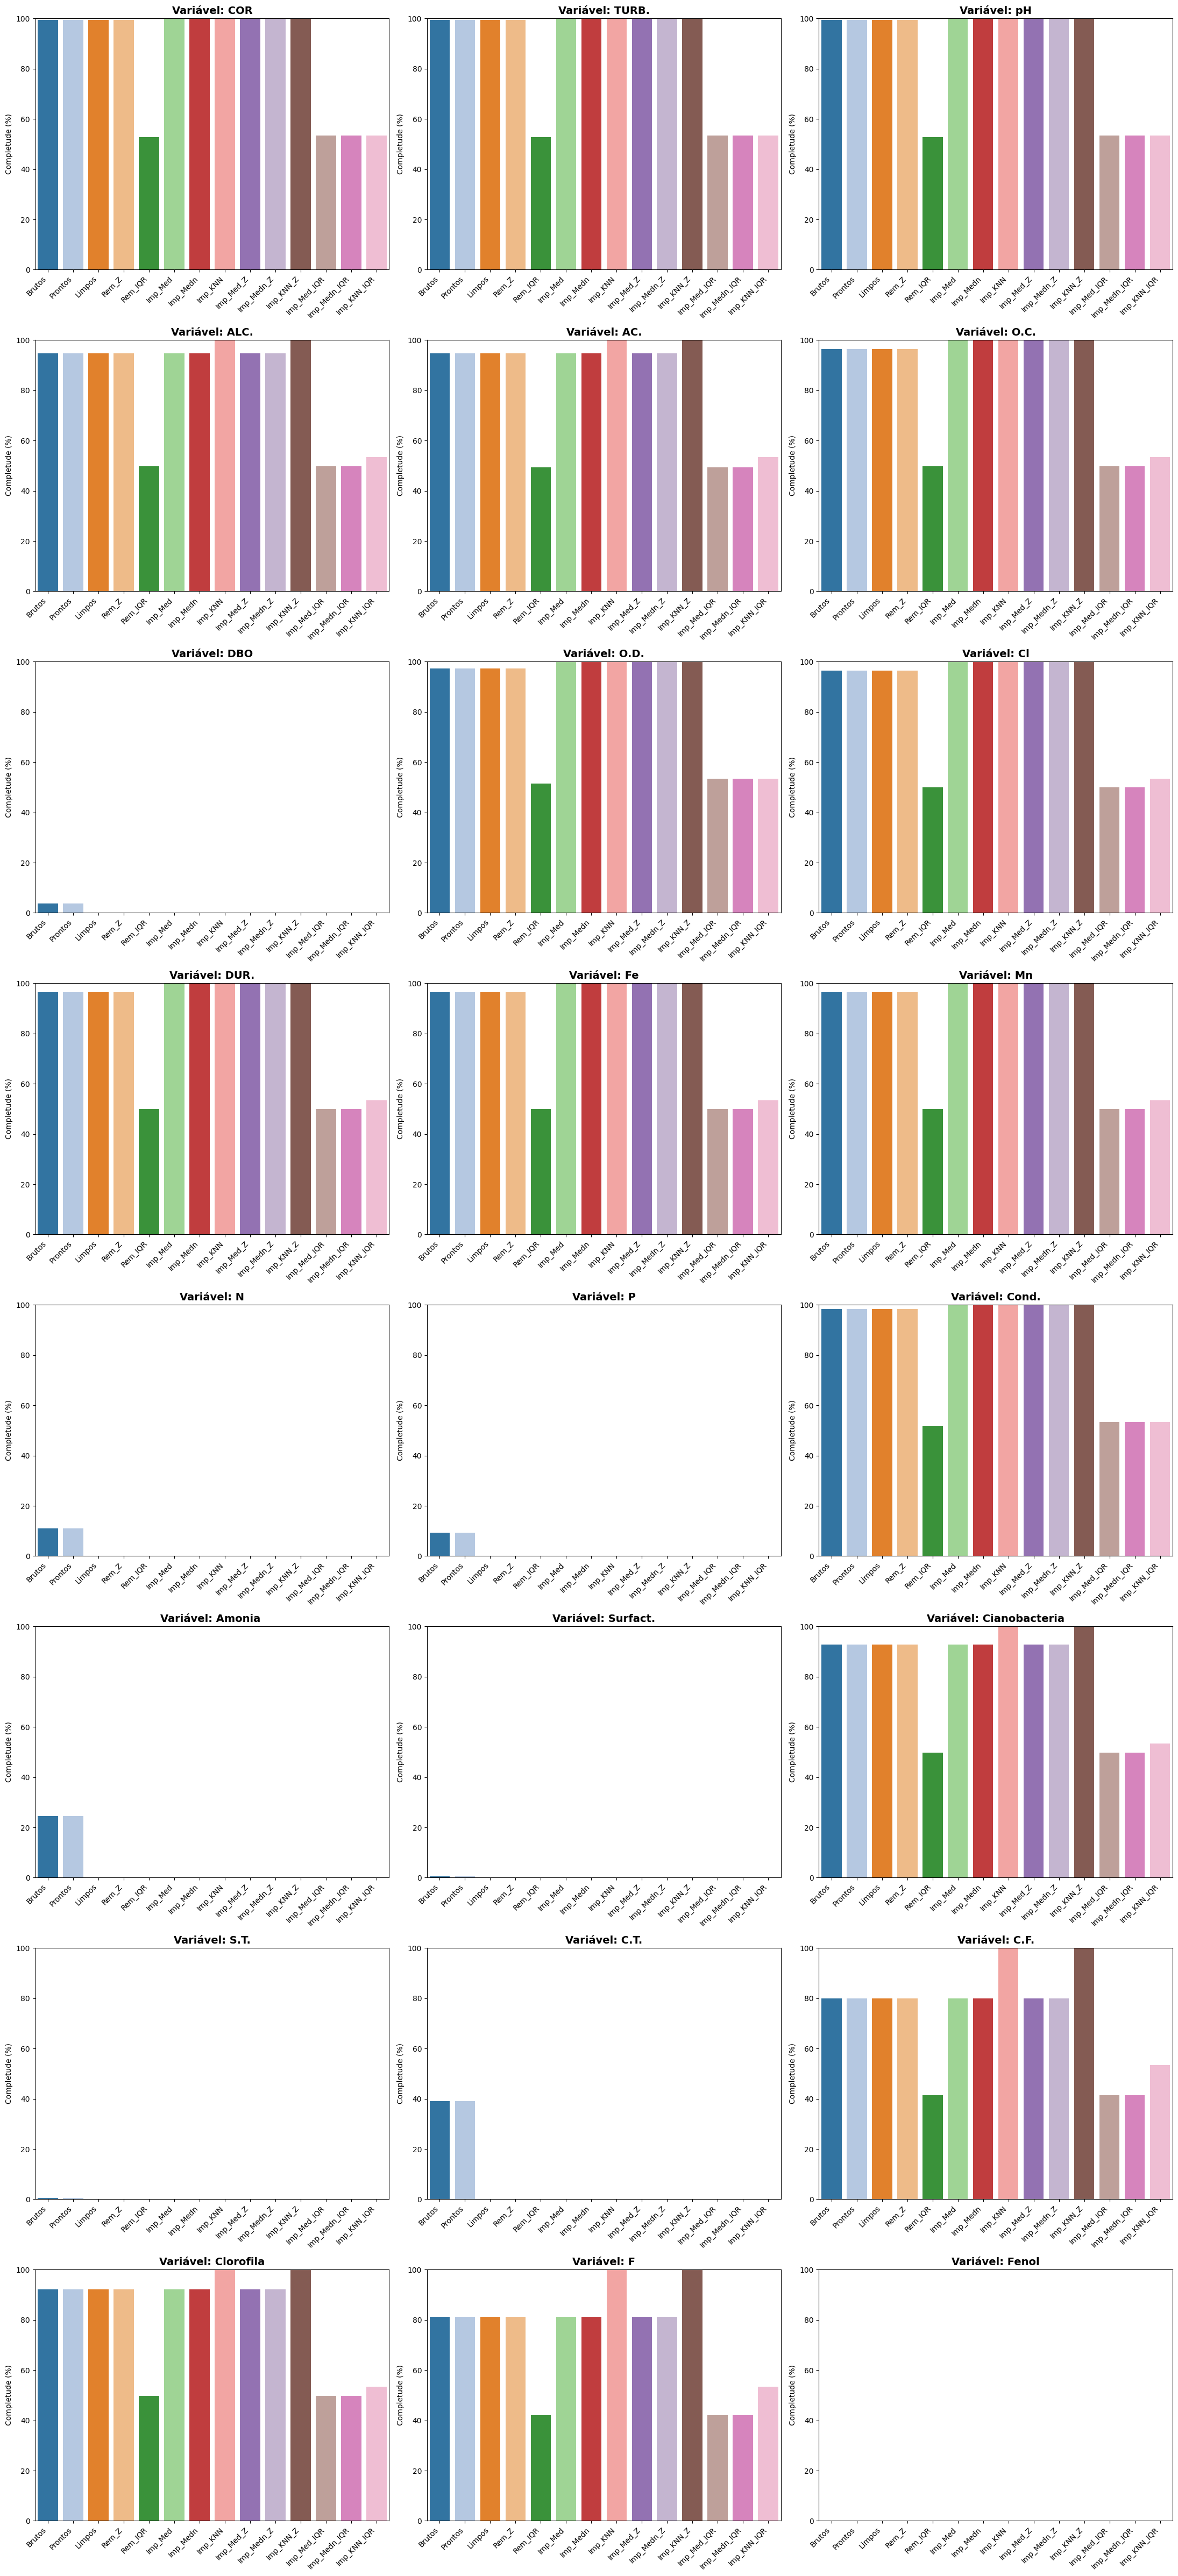

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

nomes_bases = [
    'Brutos', 'Prontos', 'Limpos', 'Rem_Z', 'Rem_IQR', 
    'Imp_Med', 'Imp_Medn', 'Imp_KNN', 
    'Imp_Med_Z', 'Imp_Medn_Z', 'Imp_KNN_Z', 
    'Imp_Med_IQR', 'Imp_Medn_IQR', 'Imp_KNN_IQR'
]

# --- DEFININDO AS CORES (Mesma lógica do anterior para consistência) ---
paleta = sns.color_palette("tab20", len(nomes_bases))
cores_das_bases = {base: cor for base, cor in zip(nomes_bases, paleta)}

# 1. Pegar o total máximo de linhas da primeira base
total_linhas_maximo = len(data_bases[0]) 
resumo_porcentagens = {}

for variavel in variaveis:
    porcentagens_desta_variavel = []
    
    for base in data_bases:
        if variavel in base.columns:
            coluna_numerica = pd.to_numeric(base[variavel], errors='coerce')
            qtd_validos = coluna_numerica.count()
        else:
            qtd_validos = 0
            
        porcentagem = (qtd_validos / total_linhas_maximo) * 100
        porcentagens_desta_variavel.append(porcentagem)
        
    resumo_porcentagens[variavel] = porcentagens_desta_variavel

num_variaveis = len(variaveis)
colunas_no_grafico = 3
linhas_no_grafico = math.ceil(num_variaveis / colunas_no_grafico) 

# --- AJUSTANDO O ESPAÇO ---
fig, axes = plt.subplots(linhas_no_grafico, colunas_no_grafico, figsize=(22, 6 * linhas_no_grafico))
axes = axes.flatten()

for i, variavel in enumerate(variaveis):
    ax = axes[i]
    
    # --- APLICANDO A COR PARA CADA BARRA ---
    # Usamos o parâmetro 'hue' e 'palette' no Seaborn para mapear as cores
    sns.barplot(
        x=nomes_bases, 
        y=resumo_porcentagens[variavel], 
        ax=ax, 
        hue=nomes_bases,               # A cor varia conforme o nome da base
        palette=cores_das_bases,       # Passamos o nosso dicionário de cores
        legend=False                   # Desligamos a legenda lateral para não poluir
    )
    
    ax.set_ylim(0, 100) 
    ax.set_title(f'Variável: {variavel}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Completude (%)') 
    
    # --- MELHORANDO A LEITURA DO EIXO X ---
    ax.set_xticks(range(len(nomes_bases)))
    ax.set_xticklabels(nomes_bases, rotation=45, ha='right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

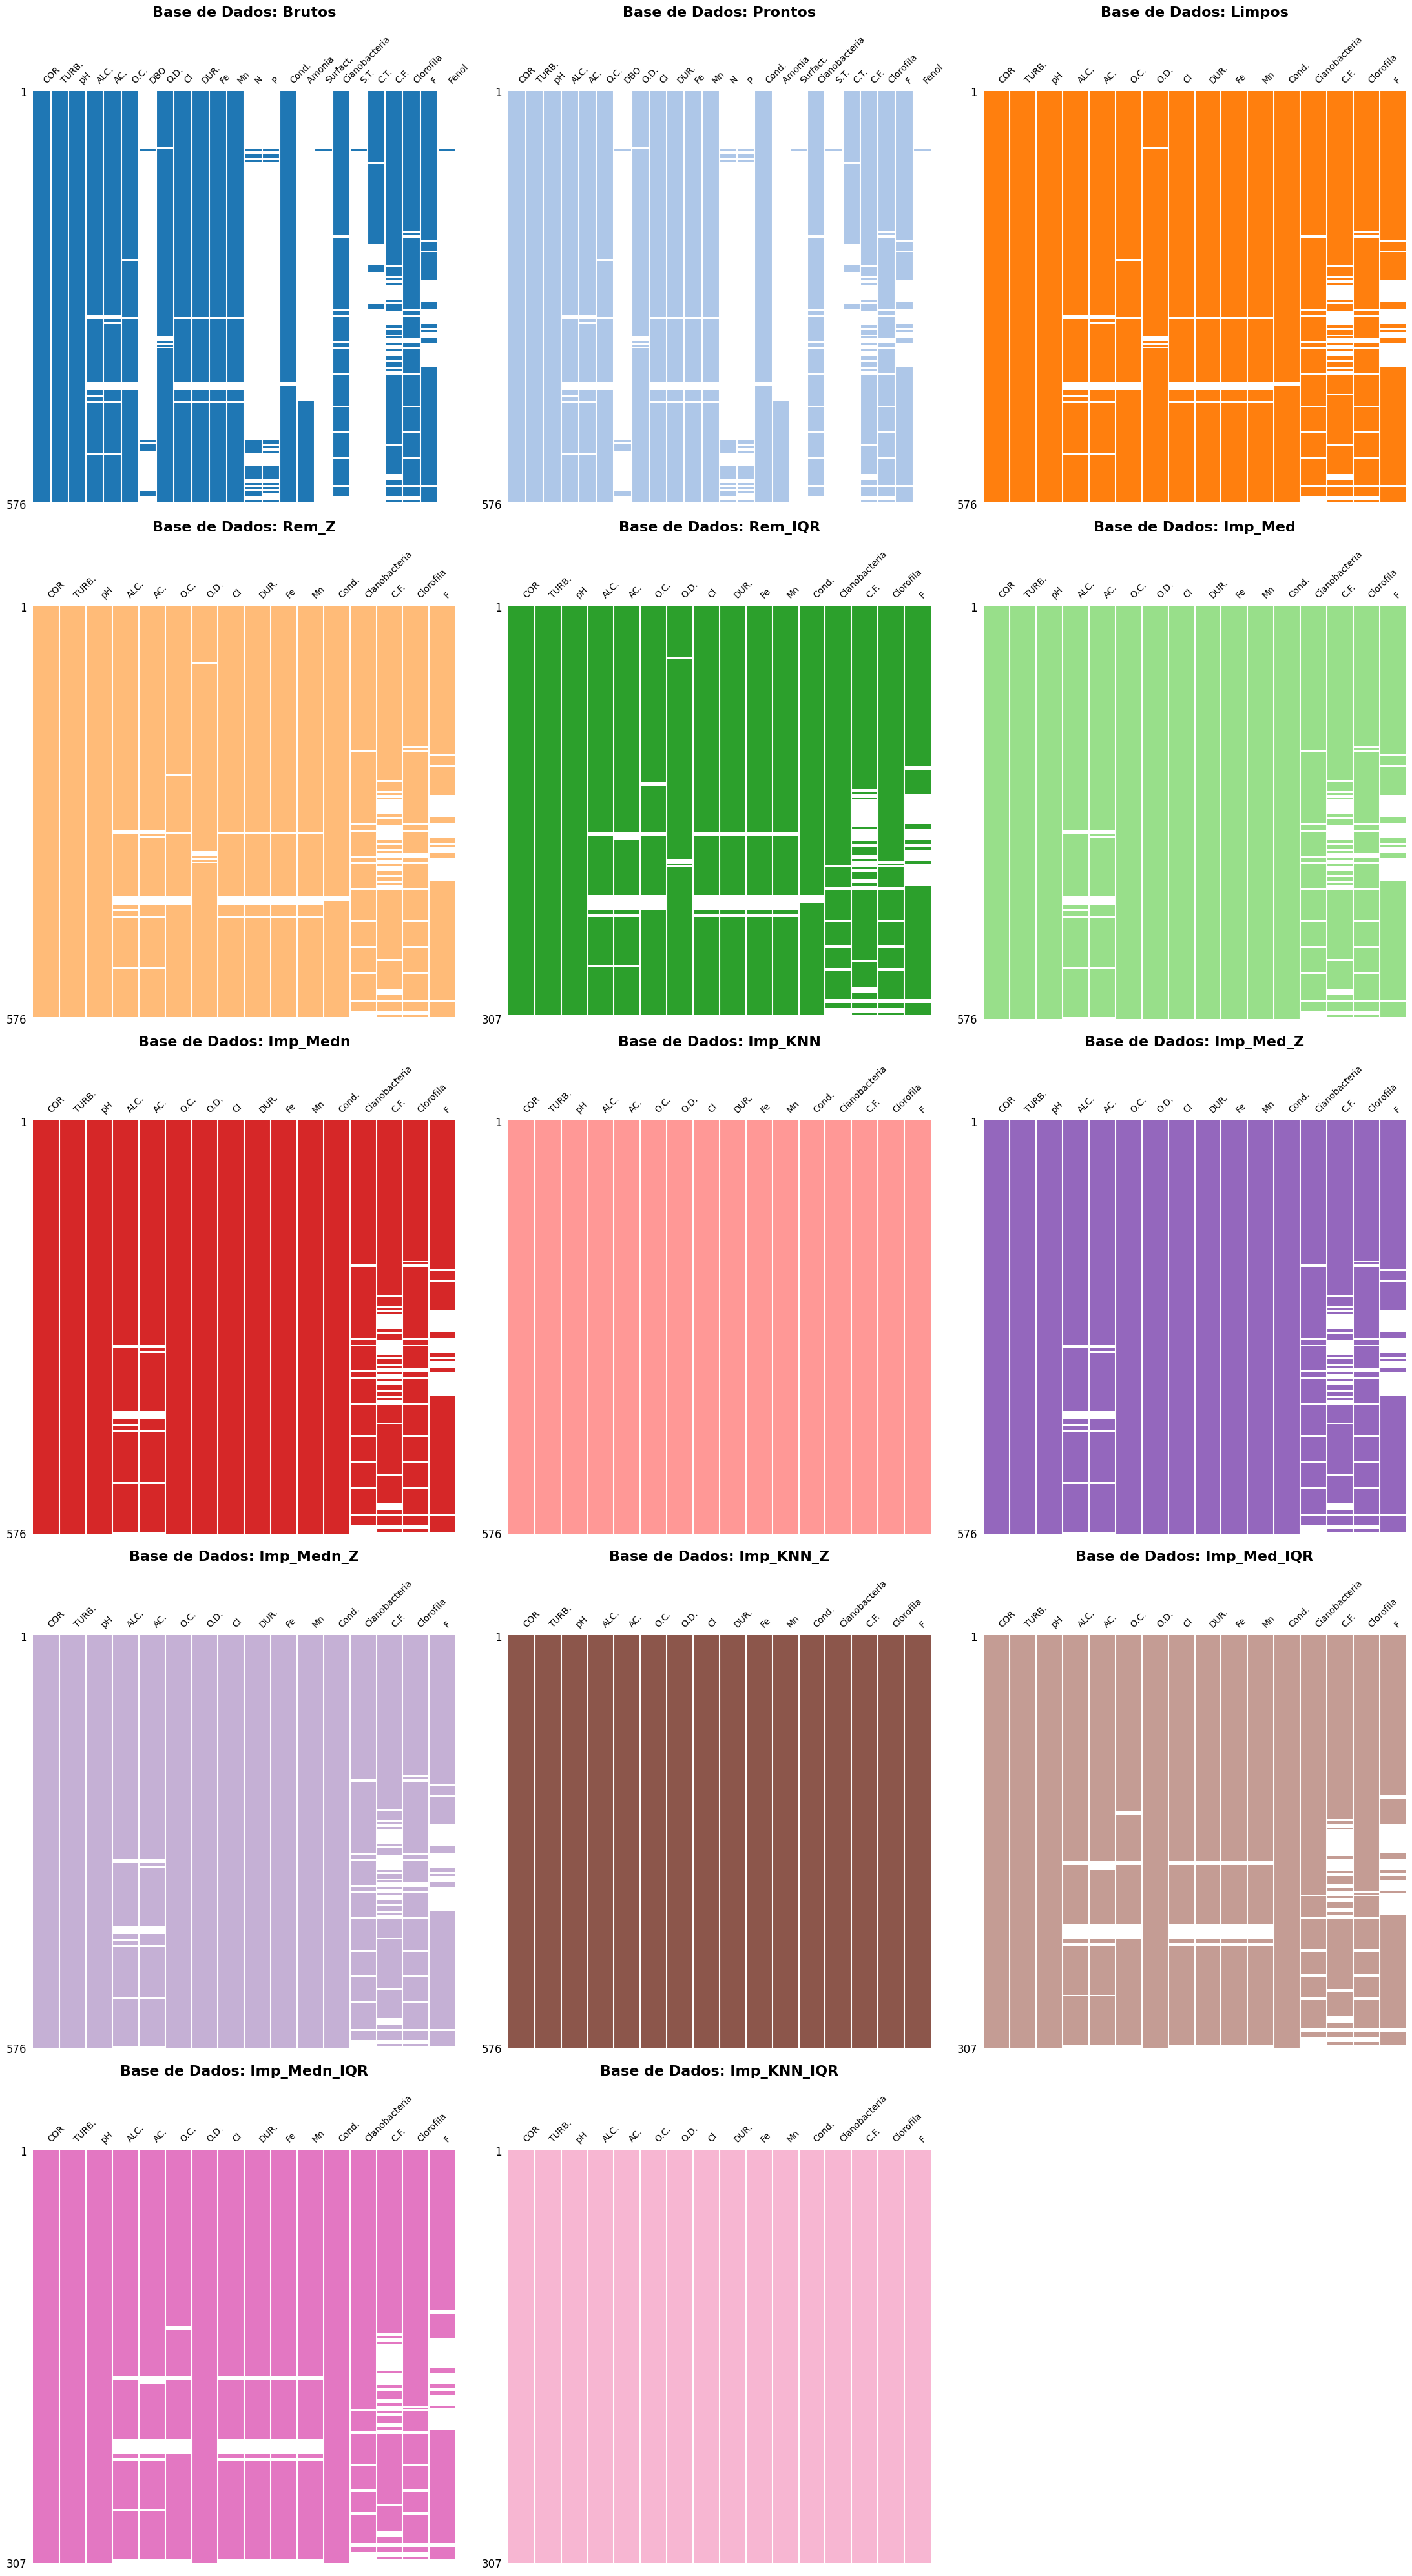

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import missingno as msno # Não esqueça de importar a biblioteca!

nomes_bases = [
    'Brutos', 'Prontos', 'Limpos', 'Rem_Z', 'Rem_IQR', 
    'Imp_Med', 'Imp_Medn', 'Imp_KNN', 
    'Imp_Med_Z', 'Imp_Medn_Z', 'Imp_KNN_Z', 
    'Imp_Med_IQR', 'Imp_Medn_IQR', 'Imp_KNN_IQR'
]

# --- MANTENDO O PADRÃO DE CORES ---
paleta = sns.color_palette("tab20", len(nomes_bases))
cores_das_bases = {base: cor for base, cor in zip(nomes_bases, paleta)}

num_bases = len(nomes_bases)
colunas_no_grafico = 3
linhas_no_grafico = math.ceil(num_bases / colunas_no_grafico) 

# Ajustamos o tamanho da figura (matrizes do missingno precisam de boa altura para mostrar as linhas)
fig, axes = plt.subplots(linhas_no_grafico, colunas_no_grafico, figsize=(22, 8 * linhas_no_grafico))
axes = axes.flatten()

for i, base in enumerate(data_bases):
    ax = axes[i]
    nome_da_base = nomes_bases[i]
    
    # É uma boa prática garantir que estamos plotando apenas as colunas de interesse
    colunas_presentes = [var for var in variaveis if var in base.columns]
    df_filtrado = base[colunas_presentes]
    
    # --- PLOTANDO A MATRIX DO MISSINGNO ---
    # Passamos o dataframe, o eixo (ax) e a cor específica da base
    msno.matrix(
        df_filtrado, 
        ax=ax, 
        color=cores_das_bases[nome_da_base], # Aqui aplicamos a cor!
        sparkline=False,                     # DESLIGADO: fundamental para não quebrar o layout da grade
        fontsize=10                          # Tamanho da fonte dos rótulos do eixo X
    )
    
    # Título do gráfico (precisamos afastar um pouco do gráfico com o 'pad' porque o msno usa o topo do eixo)
    ax.set_title(f'Base de Dados: {nome_da_base}', fontsize=16, fontweight='bold', pad=20)

# Remover os gráficos vazios no final da grade, se houver
for j in range(num_bases, len(axes)):
    fig.delaxes(axes[j])

# plt.tight_layout() pode bugar um pouco com o missingno, então usamos um ajuste manual leve se necessário.
# Mas em geral, com o sparkline=False, ele funciona bem.
plt.tight_layout()
plt.show()

In [ ]:
# Referências para essa tentativa:
### https://www.statology.org/seaborn-multiple-plots/
### https://stackoverflow.com/questions/64145095/how-to-plot-data-from-multiple-dataframes-with-seaborn-relplot

variaveis = []
for variavel in dados_prontos.columns:
    variaveis.append(variavel)

for metadado in METADADOS:
    variaveis.remove(metadado)

data_bases = [dados_brutos, dados_prontos, dados_limpos, 
              remocao_z_score, remocao_iqr, 
              imput_media, imput_mediana, imput_KNN, 
              imput_media_zscore, imput_mediana_zscore, imput_KNN_zscore, 
              imput_media_iqr, imput_mediana_iqr, imput_KNN_iqr]

df = pd.DataFrame

df = pd.concat(data_bases[0], data_bases[1], data_bases[2], data_bases[3],
               data_bases[4], data_bases[5], data_bases[6], data_bases[7],
               data_bases[8], data_bases[9], data_bases[10], data_bases[11],
               data_bases[12], data_bases[13])

df

TypeError: concat() takes 1 positional argument but 14 were given

In [ ]:
# Referências para essa tentativa:
### https://www.statology.org/seaborn-multiple-plots/
### https://stackoverflow.com/questions/64145095/how-to-plot-data-from-multiple-dataframes-with-seaborn-relplot

variaveis = []
for variavel in dados_prontos.columns:
    variaveis.append(variavel)

for metadado in METADADOS:
    variaveis.remove(metadado)

data_bases = [dados_brutos, dados_prontos, dados_limpos, 
              remocao_z_score, remocao_iqr, 
              imput_media, imput_mediana, imput_KNN, 
              imput_media_zscore, imput_mediana_zscore, imput_KNN_zscore, 
              imput_media_iqr, imput_mediana_iqr, imput_KNN_iqr]



TypeError: concat() takes 1 positional argument but 14 were given